In [30]:
import pandas as pd
from sqlalchemy import create_engine, text
from pathlib import Path
import requests

# Prueba Técnica

## Ejercicio 1

In [31]:
db_path = Path("data.db")
carpeta = Path("carpeta")

In [32]:
#crear conexion
engine = create_engine(f"sqlite:///{db_path.as_posix()}",future=True)

In [33]:
db_path.resolve()

PosixPath('/content/data.db')

In [34]:
carpeta.resolve()

PosixPath('/content/carpeta')

### Conexión archivo CSV

In [35]:
link = "https://raw.githubusercontent.com/SebasLaR/CSV/refs/heads/main/prueba_tracking_analytics_dataset.csv"
df = pd.read_csv(link)

### ETL Campaings

In [36]:
campaigns = df.iloc[0:11].reset_index()
campaigns.columns = ['campaign_id', 'name', 'start_date', 'end_date']
campaigns = campaigns.iloc[1:].reset_index(drop=True)
campaigns[['end_date', 'start_date']] = campaigns[['end_date', 'start_date']].astype('datetime64[ns]')
campaigns['campaign_id'] = campaigns['campaign_id'].astype('int64')

In [37]:
campaigns.to_sql("campaigns",con=engine,if_exists="replace",index=False,method='multi')

10

In [38]:
with engine.connect() as conn:
    consulta2_ = text("""
    SELECT *
    FROM campaigns
    """)
    consulta_Cam = pd.read_sql(consulta2_,conn)
consulta_Cam

,campaign_id,name,start_date,end_date
0,101,Verano 2024,2024-01-01 00:00:00.000000,2024-02-15 00:00:00.000000
1,102,Back to School,2024-02-16 00:00:00.000000,2024-03-10 00:00:00.000000
2,103,Dia de la Madre,2024-04-15 00:00:00.000000,2024-05-20 00:00:00.000000
3,104,Hot Sale,2024-06-01 00:00:00.000000,2024-06-10 00:00:00.000000
4,105,Vacaciones,2024-07-01 00:00:00.000000,2024-07-31 00:00:00.000000
5,106,Regreso a Clases,2024-08-01 00:00:00.000000,2024-08-20 00:00:00.000000
6,107,Cyber Week,2024-09-01 00:00:00.000000,2024-09-07 00:00:00.000000
7,108,Halloween,2024-10-01 00:00:00.000000,2024-10-31 00:00:00.000000
8,109,Black Friday,2024-11-20 00:00:00.000000,2024-11-30 00:00:00.000000
9,110,Navidad,2024-12-01 00:00:00.000000,2024-12-31 00:00:00.000000


### ETL Clicks

In [39]:
clicks = df.iloc[12:147].reset_index()
clicks.columns = ['click_id', 'campaign_id', 'user_id', 'click_date']
clicks = clicks.iloc[1:].reset_index(drop=True)
clicks[['click_date']] = clicks[['click_date']].astype('datetime64[ns]')
clicks[['click_id','campaign_id','user_id']] = clicks[['click_id','campaign_id','user_id']].astype('int64')


In [40]:
clicks.to_sql("clicks",con=engine,if_exists="replace",index=False,method='multi')

134

In [41]:
with engine.connect() as conn:
    consulta2_ = text("""
    SELECT *
    FROM clicks
    """)
    consulta_C = pd.read_sql(consulta2_,conn)
consulta_C

,click_id,campaign_id,user_id,click_date
0,1,101,5029,2024-01-02 00:00:00.000000
1,2,101,5190,2024-01-18 00:00:00.000000
2,3,101,5063,2024-01-15 00:00:00.000000
3,4,101,5036,2024-01-07 00:00:00.000000
4,5,101,5174,2024-02-04 00:00:00.000000
...,...,...,...,...
129,130,110,5132,2024-12-08 00:00:00.000000
130,131,110,5072,2024-12-22 00:00:00.000000
131,132,110,5125,2024-12-07 00:00:00.000000
132,133,110,5139,2024-12-05 00:00:00.000000


### ETL impressions

In [42]:
impressions = df.iloc[147:159, :1].reset_index()
impressions = impressions.iloc[:, :2]
impressions.columns = ['campaign_id', 'impressions']
impressions = impressions.iloc[1:].reset_index(drop=True)
impressions[['campaign_id', 'impressions']] = impressions[['campaign_id', 'impressions']].apply(pd.to_numeric, errors='coerce').astype('Int64')

In [43]:
impressions.to_sql("impressions",con=engine,if_exists="replace",index=False,method='multi')

11

### Solucion

<Axes: title={'center': 'Clicks por campaña'}, xlabel='name'>

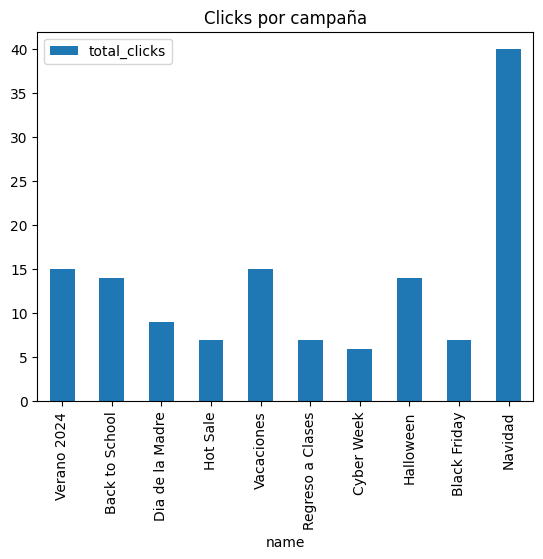

In [44]:
# Escribe una consulta SQL que obtenga el número total de clics por campaña.
with engine.connect() as conn:
    consulta = text("""
        SELECT
            c.campaign_id,
            c.name,
            COUNT(cl.click_id) AS total_clicks
        FROM campaigns AS c
        LEFT JOIN clicks AS cl
            ON c.campaign_id = cl.campaign_id
        GROUP BY c.campaign_id, c.name
        ORDER BY c.campaign_id ASC;
    """)

    resultado = pd.read_sql(consulta, conn)

resultado.plot(kind='bar', x='name', y='total_clicks', title='Clicks por campaña')

<Axes: title={'center': 'Usuarios únicos por campaña'}, xlabel='name'>

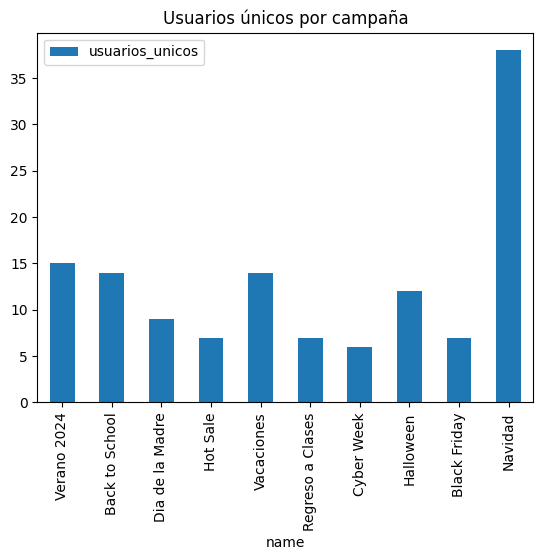

In [45]:
# Agrega una columna que indique el número de usuarios únicos por campaña.
with engine.connect() as conn:
    consulta = text("""
        SELECT
            c.campaign_id,
            c.name,
            COUNT(cl.click_id) AS total_clicks,
            COUNT(DISTINCT cl.user_id) AS usuarios_unicos
        FROM campaigns AS c
        LEFT JOIN clicks AS cl
            ON c.campaign_id = cl.campaign_id
        GROUP BY c.campaign_id, c.name
        ORDER BY c.campaign_id;
    """)

    resultado1 = pd.read_sql(consulta, conn)
resultado1.plot(kind='bar', x='name', y='usuarios_unicos', title='Usuarios únicos por campaña')

<Axes: title={'center': 'CTR por campaña'}, xlabel='name'>

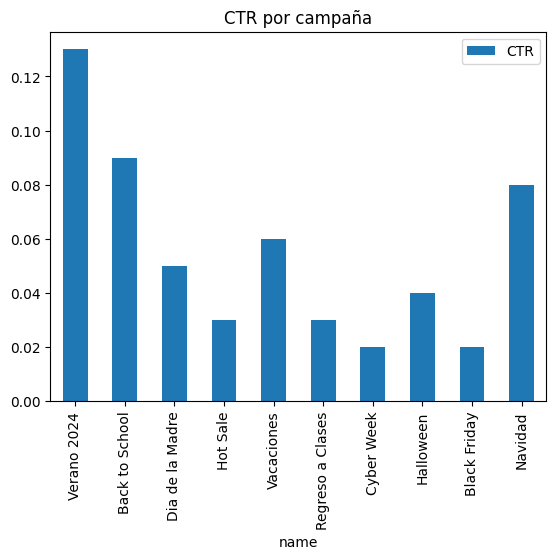

In [46]:
#Calcula el CTR (Click Through Rate), para esto, utilice la tabla de
#impressions(campaign_id, impressions).
with engine.connect() as conn:
    consulta = text("""
        SELECT
            c.campaign_id,
            c.name,
            COUNT(cl.click_id) AS total_clicks,
            i.impressions,
            ROUND((COUNT(cl.click_id) * 100.0) / NULLIF(i.impressions, 0), 2) AS CTR
        FROM campaigns AS c
        LEFT JOIN clicks AS cl
            ON c.campaign_id = cl.campaign_id
        LEFT JOIN impressions AS i
            ON c.campaign_id = i.campaign_id
        GROUP BY c.campaign_id,c.name,i.impressions
        ORDER BY c.campaign_id;
    """)

    resultado3 = pd.read_sql(consulta, conn)

resultado3.plot(kind='bar', x='name', y='CTR', title='CTR por campaña')

## Ejercicio 2


In [47]:
# 1. Haga una conexión a una API pública (por ejemplo, https://jsonplaceholder.typicode.com/posts).
url = "https://jsonplaceholder.typicode.com/posts"
respuesta = requests.get(url)
respuesta.raise_for_status()
datos = respuesta.json()

In [48]:
# 2.Extraiga los datos y los transforme en un DataFrame (pandas).
df = pd.DataFrame(datos)
# 3.Filtre los registros que contengan más de 50 caracteres en el campo title.
df_filtrado = df[df["title"].str.len() > 50].copy()

In [50]:
# 4. Cargue los resultados transformados en un archivo CSV.
df_filtrado.to_csv("posts_filtrados.csv", index=False)

In [51]:
print("Proceso ETL completado.")
print(f"Registros extraídos: {len(df)}")
print(f"Registros después del filtro: {len(df_filtrado)}")
print("Archivo generado: posts_filtrados.csv")

Proceso ETL completado.
Registros extraídos: 100
Registros después del filtro: 22
Archivo generado: posts_filtrados.csv


In [49]:
df_filtrado

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
15,2,16,sint suscipit perspiciatis velit dolorum rerum...,suscipit nam nisi quo aperiam aut\nasperiores ...
20,3,21,asperiores ea ipsam voluptatibus modi minima q...,repellat aliquid praesentium dolorem quo\nsed ...
37,4,38,explicabo et eos deleniti nostrum ab id repell...,animi esse sit aut sit nesciunt assumenda eum ...
41,5,42,commodi ullam sint et excepturi error explicab...,odio fugit voluptatum ducimus earum autem est ...
42,5,43,eligendi iste nostrum consequuntur adipisci pr...,similique fugit est\nillum et dolorum harum et...
44,5,45,ut numquam possimus omnis eius suscipit laudan...,est natus reiciendis nihil possimus aut provid...
48,5,49,laborum non sunt aut ut assumenda perspiciatis...,inventore ab sint\nnatus fugit id nulla sequi ...
49,5,50,repellendus qui recusandae incidunt voluptates...,error suscipit maxime adipisci consequuntur re...
